# Project: Wrangling and Analyze Data

In [3]:
import pandas as pd
import numpy as np
import json

## Data Gathering
In the cell below, gather **all** three pieces of data for this project and load them in the notebook. **Note:** the methods required to gather each data are different.
1. Directly download the WeRateDogs Twitter archive data (twitter_archive_enhanced.csv)

In [4]:
df_archive = pd.read_csv("twitter-archive-enhanced.csv")

2. Use the Requests library to download the tweet image prediction (image_predictions.tsv)

In [5]:
import requests
import os 
folder_name = 'new_folder'
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
url="https://d17h27t6h515a5.cloudfront.net/topher/2017/August/599fd2ad_image-predictions/image-predictions.tsv"
r = requests.get(url)
r.status_code
with open(os.path.join(folder_name, url.split('/')[-1]), mode = 'wb') as file:
    file.write(r.content)
image_df = pd.read_csv(url, sep='\t')


image_df.head()

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True


3. Use the Tweepy library to query additional data via the Twitter API (tweet_json.txt)

In [6]:
import json

# Create a list to store each tweet's data
tweet_data = []

# Open the file and read each line
with open('tweet-json.txt', 'r') as file:
    for line in file:
        try:
            tweet = json.loads(line)
            tweet_data.append({
                'tweet_id': tweet['id_str'],
                'retweet_count': tweet['retweet_count'],
                'favorite_count': tweet['favorite_count']
            })
        except json.JSONDecodeError:
            continue  # skip broken lines

# Create a DataFrame
tweet_df = pd.DataFrame(tweet_data)

# Show the DataFrame
tweet_df.head()


,favorite_count,retweet_count,tweet_id
0,39467,8853,892420643555336193
1,33819,6514,892177421306343426
2,25461,4328,891815181378084864
3,42908,8964,891689557279858688
4,41048,9774,891327558926688256


## Assessing Data
In this section, detect and document at least **eight (8) quality issues and two (2) tidiness issue**. You must use **both** visual assessment
programmatic assessement to assess the data.

**Note:** pay attention to the following key points when you access the data.

* You only want original ratings (no retweets) that have images. Though there are 5000+ tweets in the dataset, not all are dog ratings and some are retweets.
* Assessing and cleaning the entire dataset completely would require a lot of time, and is not necessary to practice and demonstrate your skills in data wrangling. Therefore, the requirements of this project are only to assess and clean at least 8 quality issues and at least 2 tidiness issues in this dataset.
* The fact that the rating numerators are greater than the denominators does not need to be cleaned. This [unique rating system](http://knowyourmeme.com/memes/theyre-good-dogs-brent) is a big part of the popularity of WeRateDogs.
* You do not need to gather the tweets beyond August 1st, 2017. You can, but note that you won't be able to gather the image predictions for these tweets since you don't have access to the algorithm used.



In [7]:
df_archive.head(10)

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,NaN,NaN,2017-08-01 16:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,None,None,None,None
1,892177421306343426,NaN,NaN,2017-08-01 00:17:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,None,None,None,None
2,891815181378084864,NaN,NaN,2017-07-31 00:18:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,None,None,None,None
3,891689557279858688,NaN,NaN,2017-07-30 15:58:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,None,None,None,None
4,891327558926688256,NaN,NaN,2017-07-29 16:00:24 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,12,10,Franklin,None,None,None,None
5,891087950875897856,NaN,NaN,2017-07-29 00:08:17 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here we have a majestic great white breaching ...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891087950...,13,10,None,None,None,None,None
6,890971913173991426,NaN,NaN,2017-07-28 16:27:12 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Meet Jax. He enjoys ice cream so much he gets ...,NaN,NaN,NaN,"https://gofundme.com/ydvmve-surgery-for-jax,ht...",13,10,Jax,None,None,None,None
7,890729181411237888,NaN,NaN,2017-07-28 00:22:40 +0000,"<a href=""http://twitter.com/download/iphone"" r...",When you watch your owner call another dog a g...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/890729181...,13,10,None,None,None,None,None
8,890609185150312448,NaN,NaN,2017-07-27 16:25:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Zoey. She doesn't want to be one of th...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/890609185...,13,10,Zoey,None,None,None,None
9,890240255349198849,NaN,NaN,2017-07-26 15:59:51 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Cassie. She is a college pup. Studying...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/890240255...,14,10,Cassie,doggo,None,None,None


In [8]:
image_df.head()

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True


In [9]:
tweet_df.head()

,favorite_count,retweet_count,tweet_id
0,39467,8853,892420643555336193
1,33819,6514,892177421306343426
2,25461,4328,891815181378084864
3,42908,8964,891689557279858688
4,41048,9774,891327558926688256


In [10]:
df_archive.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 17 columns):
tweet_id                      2356 non-null int64
in_reply_to_status_id         78 non-null float64
in_reply_to_user_id           78 non-null float64
timestamp                     2356 non-null object
source                        2356 non-null object
text                          2356 non-null object
retweeted_status_id           181 non-null float64
retweeted_status_user_id      181 non-null float64
retweeted_status_timestamp    181 non-null object
expanded_urls                 2297 non-null object
rating_numerator              2356 non-null int64
rating_denominator            2356 non-null int64
name                          2356 non-null object
doggo                         2356 non-null object
floofer                       2356 non-null object
pupper                        2356 non-null object
puppo                         2356 non-null object
dtypes: float64(4), int64(3), ob

In [11]:
image_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 12 columns):
tweet_id    2075 non-null int64
jpg_url     2075 non-null object
img_num     2075 non-null int64
p1          2075 non-null object
p1_conf     2075 non-null float64
p1_dog      2075 non-null bool
p2          2075 non-null object
p2_conf     2075 non-null float64
p2_dog      2075 non-null bool
p3          2075 non-null object
p3_conf     2075 non-null float64
p3_dog      2075 non-null bool
dtypes: bool(3), float64(3), int64(2), object(4)
memory usage: 152.1+ KB


In [12]:
df_archive["name"].value_counts()

None         745
a             55
Charlie       12
Cooper        11
Lucy          11
Oliver        11
Lola          10
Penny         10
Tucker        10
Bo             9
Winston        9
the            8
Sadie          8
Toby           7
an             7
Daisy          7
Bailey         7
Buddy          7
Scout          6
Dave           6
Stanley        6
Bella          6
Jax            6
Rusty          6
Jack           6
Milo           6
Koda           6
Oscar          6
Leo            6
Alfie          5
            ... 
Buddah         1
Tobi           1
Jeremy         1
Ricky          1
Walker         1
Eevee          1
Gustaf         1
Rizzo          1
Stewie         1
Laela          1
Kathmandu      1
Aqua           1
Rufio          1
Gin            1
Sweet          1
Bayley         1
Zara           1
Stu            1
Kramer         1
Comet          1
Vinnie         1
Mabel          1
Remus          1
Sora           1
Kawhi          1
Stella         1
O              1
Craig         

In [13]:
df_archive.duplicated().sum()

0

In [14]:
all_columns = pd.Series(list(df_archive) + list(image_df) + list(tweet_df))
all_columns[all_columns.duplicated()]

17    tweet_id
31    tweet_id
dtype: object

In [15]:
image_df.p1_conf.sort_values()

38      0.044333
136     0.055379
1093    0.059033
1370    0.063152
246     0.070076
250     0.071124
145     0.071536
680     0.072885
701     0.081101
1831    0.082489
18      0.086502
109     0.088530
568     0.088540
301     0.089165
1627    0.090341
1503    0.090341
954     0.090508
277     0.096063
2074    0.097049
664     0.097232
789     0.097500
515     0.098283
1664    0.099804
731     0.100499
1723    0.100896
1037    0.105171
247     0.107317
876     0.107948
866     0.110587
1245    0.111493
          ...   
76      0.999091
1988    0.999120
2045    0.999201
863     0.999223
1872    0.999281
1548    0.999306
95      0.999335
611     0.999365
1711    0.999403
512     0.999484
168     0.999614
107     0.999647
1796    0.999715
1455    0.999823
1687    0.999828
1725    0.999833
331     0.999834
1014    0.999837
594     0.999846
475     0.999876
865     0.999885
45      0.999888
1447    0.999916
242     0.999924
230     0.999945
1372    0.999953
149     0.999956
1229    0.9999

In [16]:
image_df.p2_conf.sort_values()

106     1.011300e-08
1299    1.002880e-05
1229    1.448950e-05
230     1.763430e-05
1372    2.335910e-05
242     2.987300e-05
149     4.309810e-05
1796    4.629670e-05
45      5.514170e-05
1455    5.644850e-05
475     5.867490e-05
1711    6.229490e-05
1687    6.780610e-05
594     7.191480e-05
1447    7.657020e-05
95      8.106320e-05
331     8.675670e-05
865     9.758170e-05
1548    1.131290e-04
1014    1.169070e-04
1536    1.529990e-04
512     1.582170e-04
513     1.589610e-04
1725    1.596210e-04
107     1.811500e-04
863     1.865250e-04
94      2.010840e-04
168     2.280900e-04
2045    3.611780e-04
1872    3.700800e-04
            ...     
650     4.034200e-01
869     4.034510e-01
2037    4.042910e-01
13      4.047220e-01
2030    4.060440e-01
186     4.065500e-01
662     4.111820e-01
1834    4.140020e-01
1904    4.153740e-01
1219    4.164780e-01
1036    4.184830e-01
601     4.201190e-01
127     4.253030e-01
721     4.302750e-01
1046    4.306240e-01
605     4.316570e-01
1436    4.321

In [17]:
image_df.p3_conf.sort_values()

106     1.740170e-10
149     2.160900e-07
1906    5.595040e-07
1760    8.832830e-07
1299    1.434470e-06
1725    1.799800e-06
1447    2.164680e-06
1372    3.010330e-06
1229    6.060880e-06
865     8.267760e-06
1014    1.133840e-05
230     1.470730e-05
242     2.150760e-05
879     2.322000e-05
172     2.335260e-05
45      2.625800e-05
1455    2.768060e-05
611     2.815280e-05
475     2.877850e-05
1711    3.046190e-05
1687    3.424360e-05
1796    4.118430e-05
594     4.447290e-05
17      5.206580e-05
331     5.332190e-05
53      5.735010e-05
512     6.091100e-05
168     6.717870e-05
95      6.915900e-05
1988    7.289040e-05
            ...     
2068    1.935480e-01
922     1.940860e-01
265     1.962790e-01
1600    1.963990e-01
1012    1.967890e-01
111     1.984280e-01
1680    2.003880e-01
1416    2.017110e-01
957     2.021000e-01
1236    2.031630e-01
400     2.034950e-01
26      2.068030e-01
551     2.092130e-01
698     2.093930e-01
139     2.123810e-01
1462    2.130110e-01
1597    2.142

In [18]:
df_archive.describe()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,retweeted_status_id,retweeted_status_user_id,rating_numerator,rating_denominator
count,2.356000e+03,7.800000e+01,7.800000e+01,1.810000e+02,1.810000e+02,2356.000000,2356.000000
mean,7.427716e+17,7.455079e+17,2.014171e+16,7.720400e+17,1.241698e+16,13.126486,10.455433
std,6.856705e+16,7.582492e+16,1.252797e+17,6.236928e+16,9.599254e+16,45.876648,6.745237
min,6.660209e+17,6.658147e+17,1.185634e+07,6.661041e+17,7.832140e+05,0.000000,0.000000
25%,6.783989e+17,6.757419e+17,3.086374e+08,7.186315e+17,4.196984e+09,10.000000,10.000000
50%,7.196279e+17,7.038708e+17,4.196984e+09,7.804657e+17,4.196984e+09,11.000000,10.000000
75%,7.993373e+17,8.257804e+17,4.196984e+09,8.203146e+17,4.196984e+09,12.000000,10.000000
max,8.924206e+17,8.862664e+17,8.405479e+17,8.874740e+17,7.874618e+17,1776.000000,170.000000


In [19]:
df_archive[df_archive["rating_numerator"] > 20]

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
188,855862651834028034,8.558616e+17,1.943518e+08,2017-04-22 19:15:32 +0000,"<a href=""http://twitter.com/download/iphone"" r...",@dhmontgomery We also gave snoop dogg a 420/10...,NaN,NaN,NaN,NaN,420,10,None,None,None,None,None
189,855860136149123072,8.558585e+17,1.361572e+07,2017-04-22 19:05:32 +0000,"<a href=""http://twitter.com/download/iphone"" r...",@s8n You tried very hard to portray this good ...,NaN,NaN,NaN,NaN,666,10,None,None,None,None,None
290,838150277551247360,8.381455e+17,2.195506e+07,2017-03-04 22:12:52 +0000,"<a href=""http://twitter.com/download/iphone"" r...",@markhoppus 182/10,NaN,NaN,NaN,NaN,182,10,None,None,None,None,None
313,835246439529840640,8.352460e+17,2.625958e+07,2017-02-24 21:54:03 +0000,"<a href=""http://twitter.com/download/iphone"" r...",@jonnysun @Lin_Manuel ok jomny I know you're e...,NaN,NaN,NaN,NaN,960,0,None,None,None,None,None
340,832215909146226688,NaN,NaN,2017-02-16 13:11:49 +0000,"<a href=""http://twitter.com/download/iphone"" r...","RT @dog_rates: This is Logan, the Chow who liv...",7.867091e+17,4.196984e+09,2016-10-13 23:23:56 +0000,https://twitter.com/dog_rates/status/786709082...,75,10,Logan,None,None,None,None
433,820690176645140481,NaN,NaN,2017-01-15 17:52:40 +0000,"<a href=""http://twitter.com/download/iphone"" r...",The floofs have been released I repeat the flo...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/820690176...,84,70,None,None,None,None,None
516,810984652412424192,NaN,NaN,2016-12-19 23:06:23 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Meet Sam. She smiles 24/7 &amp; secretly aspir...,NaN,NaN,NaN,"https://www.gofundme.com/sams-smile,https://tw...",24,7,Sam,None,None,None,None
695,786709082849828864,NaN,NaN,2016-10-13 23:23:56 +0000,"<a href=""http://twitter.com/download/iphone"" r...","This is Logan, the Chow who lived. He solemnly...",NaN,NaN,NaN,https://twitter.com/dog_rates/status/786709082...,75,10,Logan,None,None,None,None
763,778027034220126208,NaN,NaN,2016-09-20 00:24:34 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Sophie. She's a Jubilant Bush Pupper. ...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/778027034...,27,10,Sophie,None,None,pupper,None
902,758467244762497024,NaN,NaN,2016-07-28 01:00:57 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Why does this never happen at my front door......,NaN,NaN,NaN,https://twitter.com/dog_rates/status/758467244...,165,150,None,None,None,None,None


In [20]:
df_archive[df_archive["rating_denominator"] == 170]

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
1120,731156023742988288,NaN,NaN,2016-05-13 16:15:54 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Say hello to this unbelievably well behaved sq...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/731156023...,204,170,this,None,None,None,None


In [21]:
image_df.describe()

,tweet_id,img_num,p1_conf,p2_conf,p3_conf
count,2.075000e+03,2075.000000,2075.000000,2.075000e+03,2.075000e+03
mean,7.384514e+17,1.203855,0.594548,1.345886e-01,6.032417e-02
std,6.785203e+16,0.561875,0.271174,1.006657e-01,5.090593e-02
min,6.660209e+17,1.000000,0.044333,1.011300e-08,1.740170e-10
25%,6.764835e+17,1.000000,0.364412,5.388625e-02,1.622240e-02
50%,7.119988e+17,1.000000,0.588230,1.181810e-01,4.944380e-02
75%,7.932034e+17,1.000000,0.843855,1.955655e-01,9.180755e-02
max,8.924206e+17,4.000000,1.000000,4.880140e-01,2.734190e-01


In [22]:
tweet_df.describe()

,favorite_count,retweet_count
count,2354.000000,2354.000000
mean,8080.968564,3164.797366
std,11814.771334,5284.770364
min,0.000000,0.000000
25%,1415.000000,624.500000
50%,3603.500000,1473.500000
75%,10122.250000,3652.000000
max,132810.000000,79515.000000


In [23]:
tweet_df.duplicated().sum()

0

In [24]:
image_df.duplicated().sum()

0

In [25]:
tweet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2354 entries, 0 to 2353
Data columns (total 3 columns):
favorite_count    2354 non-null int64
retweet_count     2354 non-null int64
tweet_id          2354 non-null object
dtypes: int64(2), object(1)
memory usage: 55.2+ KB


### Quality issues
1.There are some retweets in df_archive.

2.The source column in df_archive contains HTML tags instead of clean source names.

3.In image_df, the predicted dog breeds (p1, p2, p3) have inconsistent casing (some start uppercase, others lowercase).

4.image_df has missing entries for some tweet IDs that are present in df_archive.

5.There are invalid rating denominators in df_archive (e.g., values other than 10).

6.There are some incorrect or placeholder dog names in df_archive (e.g., 'a', 'an', 'such').

7.tweet_id in df_archive is stored as an integer instead of a string.

8.There are null values in the expanded_urls column in df_archive.



### Tidiness issues
1.timestamp in df_archive has 2 variables(date and time)

2.tweet_df should be part of the df_archive table 

## Cleaning Data
In this section, clean **all** of the issues you documented while assessing. 

**Note:** Make a copy of the original data before cleaning. Cleaning includes merging individual pieces of data according to the rules of [tidy data](https://cran.r-project.org/web/packages/tidyr/vignettes/tidy-data.html). The result should be a high-quality and tidy master pandas DataFrame (or DataFrames, if appropriate).

In [26]:
# Make copies of original pieces of data
archive_clean = df_archive.copy()
image_clean = image_df.copy()
tweets_clean = tweet_df.copy()

### qulity Issue #8:There are null values in the expanded_urls column in df_archive.

#### Define:Drop  nulls in expanded_urls



code

In [27]:
archive_clean = archive_clean[archive_clean['expanded_urls'].notnull()]


test

In [28]:
archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2297 entries, 0 to 2355
Data columns (total 17 columns):
tweet_id                      2297 non-null int64
in_reply_to_status_id         23 non-null float64
in_reply_to_user_id           23 non-null float64
timestamp                     2297 non-null object
source                        2297 non-null object
text                          2297 non-null object
retweeted_status_id           180 non-null float64
retweeted_status_user_id      180 non-null float64
retweeted_status_timestamp    180 non-null object
expanded_urls                 2297 non-null object
rating_numerator              2297 non-null int64
rating_denominator            2297 non-null int64
name                          2297 non-null object
doggo                         2297 non-null object
floofer                       2297 non-null object
pupper                        2297 non-null object
puppo                         2297 non-null object
dtypes: float64(4), int64(3), ob

### tidiness Issue #1:timestamp in df_archive has 2 variables(date and time)

#### Define: Split timestamp into date , time columns

#### Code

In [29]:

archive_clean['timestamp'] = pd.to_datetime(archive_clean['timestamp'])


archive_clean['date'] = archive_clean['timestamp'].dt.date
archive_clean['time'] = archive_clean['timestamp'].dt.time

archive_clean.drop('timestamp', axis=1, inplace=True)


#### Test

In [30]:
archive_clean.head()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo,date,time
0,892420643555336193,NaN,NaN,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,None,None,None,None,2017-08-01,16:23:56
1,892177421306343426,NaN,NaN,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,None,None,None,None,2017-08-01,00:17:27
2,891815181378084864,NaN,NaN,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,None,None,None,None,2017-07-31,00:18:03
3,891689557279858688,NaN,NaN,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,None,None,None,None,2017-07-30,15:58:51
4,891327558926688256,NaN,NaN,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,12,10,Franklin,None,None,None,None,2017-07-29,16:00:24


###  quality Issue #7:tweet_id in df_archive  and in image_df is stored as an integer instead of a string.

#### Define:Convert tweet_id to string

#### Code

In [31]:
archive_clean['tweet_id'] = archive_clean['tweet_id'].astype(str)


In [32]:
image_clean['tweet_id'] = image_clean['tweet_id'].astype(str)

#### Test

In [33]:
archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2297 entries, 0 to 2355
Data columns (total 18 columns):
tweet_id                      2297 non-null object
in_reply_to_status_id         23 non-null float64
in_reply_to_user_id           23 non-null float64
source                        2297 non-null object
text                          2297 non-null object
retweeted_status_id           180 non-null float64
retweeted_status_user_id      180 non-null float64
retweeted_status_timestamp    180 non-null object
expanded_urls                 2297 non-null object
rating_numerator              2297 non-null int64
rating_denominator            2297 non-null int64
name                          2297 non-null object
doggo                         2297 non-null object
floofer                       2297 non-null object
pupper                        2297 non-null object
puppo                         2297 non-null object
date                          2297 non-null object
time                          2

In [34]:
image_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 12 columns):
tweet_id    2075 non-null object
jpg_url     2075 non-null object
img_num     2075 non-null int64
p1          2075 non-null object
p1_conf     2075 non-null float64
p1_dog      2075 non-null bool
p2          2075 non-null object
p2_conf     2075 non-null float64
p2_dog      2075 non-null bool
p3          2075 non-null object
p3_conf     2075 non-null float64
p3_dog      2075 non-null bool
dtypes: bool(3), float64(3), int64(1), object(5)
memory usage: 152.1+ KB


### tidyness Issue #2:tweet_df should be part of the df_archive table

#### Define  Merge tweet_df into df_archive

#### Code

In [35]:
archive_clean = pd.merge(archive_clean, tweets_clean,
                            on= ["tweet_id"],how="left")

#### Test

In [36]:
archive_clean.head()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo,date,time,favorite_count,retweet_count
0,892420643555336193,NaN,NaN,"<a href=""http://twitter.com/download/iphone"" r...",This is Phineas. He's a mystical boy. Only eve...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,None,None,None,None,2017-08-01,16:23:56,39467.0,8853.0
1,892177421306343426,NaN,NaN,"<a href=""http://twitter.com/download/iphone"" r...",This is Tilly. She's just checking pup on you....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,None,None,None,None,2017-08-01,00:17:27,33819.0,6514.0
2,891815181378084864,NaN,NaN,"<a href=""http://twitter.com/download/iphone"" r...",This is Archie. He is a rare Norwegian Pouncin...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,None,None,None,None,2017-07-31,00:18:03,25461.0,4328.0
3,891689557279858688,NaN,NaN,"<a href=""http://twitter.com/download/iphone"" r...",This is Darla. She commenced a snooze mid meal...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,None,None,None,None,2017-07-30,15:58:51,42908.0,8964.0
4,891327558926688256,NaN,NaN,"<a href=""http://twitter.com/download/iphone"" r...",This is Franklin. He would like you to stop ca...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/891327558...,12,10,Franklin,None,None,None,None,2017-07-29,16:00:24,41048.0,9774.0


### quality Issue #1:There are some retweets in df_archive.

#### Define:Remove retweets

#### Code

In [37]:
archive_clean = archive_clean[archive_clean['retweeted_status_id'].isnull()]

archive_clean = archive_clean.drop(columns=[
    'retweeted_status_id', 
    'retweeted_status_user_id', 
    'retweeted_status_timestamp','in_reply_to_status_id'   , 
     'in_reply_to_user_id'
])



#### Test

In [38]:
archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2117 entries, 0 to 2296
Data columns (total 15 columns):
tweet_id              2117 non-null object
source                2117 non-null object
text                  2117 non-null object
expanded_urls         2117 non-null object
rating_numerator      2117 non-null int64
rating_denominator    2117 non-null int64
name                  2117 non-null object
doggo                 2117 non-null object
floofer               2117 non-null object
pupper                2117 non-null object
puppo                 2117 non-null object
date                  2117 non-null object
time                  2117 non-null object
favorite_count        2117 non-null float64
retweet_count         2117 non-null float64
dtypes: float64(2), int64(2), object(11)
memory usage: 264.6+ KB


### quality Issue #2:The source column in df_archive contains HTML tags instead of clean source names.

#### Define:Clean up source values

#### Code

In [39]:
archive_clean["source"] = archive_clean["source"].str[9:43]

#### Test

In [40]:
archive_clean["source"]

0       http://twitter.com/download/iphone
1       http://twitter.com/download/iphone
2       http://twitter.com/download/iphone
3       http://twitter.com/download/iphone
4       http://twitter.com/download/iphone
5       http://twitter.com/download/iphone
6       http://twitter.com/download/iphone
7       http://twitter.com/download/iphone
8       http://twitter.com/download/iphone
9       http://twitter.com/download/iphone
10      http://twitter.com/download/iphone
11      http://twitter.com/download/iphone
12      http://twitter.com/download/iphone
13      http://twitter.com/download/iphone
14      http://twitter.com/download/iphone
15      http://twitter.com/download/iphone
16      http://twitter.com/download/iphone
17      http://twitter.com/download/iphone
18      http://twitter.com/download/iphone
20      http://twitter.com/download/iphone
21      http://twitter.com/download/iphone
22      http://twitter.com/download/iphone
23      http://twitter.com/download/iphone
24      htt

### quality Issue #3:In image_df, the predicted dog breeds (p1, p2, p3) have inconsistent casing (some start uppercase, others lowercase).

#### Define:Standardize p1/p2/p3 casing



#### Code

In [41]:

image_clean['p1'] = image_clean['p1'].str.lower()
image_clean['p2'] = image_clean['p2'].str.lower()
image_clean['p3'] = image_clean['p3'].str.lower()



#### Test

In [42]:
image_clean.head()

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,welsh_springer_spaniel,0.465074,True,collie,0.156665,True,shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,german_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,rottweiler,0.243682,True,doberman,0.154629,True


### quality Issue #4:image_df has missing entries for some tweet IDs that are present in df_archive

#### Define:Handle missing records from image_df

#### Code

In [43]:
common_ids = set(archive_clean['tweet_id']) & set(image_clean['tweet_id'])
archive_clean = archive_clean[archive_clean['tweet_id'].isin(common_ids)]
image_clean = image_clean[image_clean['tweet_id'].isin(common_ids)]

#### Test

In [44]:
archive_clean.shape


(1994, 15)

In [45]:
image_clean.shape


(1994, 12)

### quality Issue #5:There are invalid rating denominators  in df_archive (e.g., values other than 10).

#### Define Fix rating denominator

#### Code

In [46]:
archive_clean["rating_denominator"] = 10




In [47]:
archive_clean["rating_denominator"] = 10


In [48]:
archive_clean["rating_denominator"] = 10


#### Test

In [49]:
archive_clean.describe()

,rating_numerator,rating_denominator,favorite_count,retweet_count
count,1994.000000,1994.0,1994.000000,1994.000000
mean,12.280843,10.0,8895.725677,2766.753260
std,41.497718,0.0,12213.193181,4674.698447
min,0.000000,10.0,81.000000,16.000000
25%,10.000000,10.0,1982.000000,624.750000
50%,11.000000,10.0,4136.000000,1359.500000
75%,12.000000,10.0,11308.000000,3220.000000
max,1776.000000,10.0,132810.000000,79515.000000


In [50]:
archive_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1994 entries, 0 to 2296
Data columns (total 15 columns):
tweet_id              1994 non-null object
source                1994 non-null object
text                  1994 non-null object
expanded_urls         1994 non-null object
rating_numerator      1994 non-null int64
rating_denominator    1994 non-null int64
name                  1994 non-null object
doggo                 1994 non-null object
floofer               1994 non-null object
pupper                1994 non-null object
puppo                 1994 non-null object
date                  1994 non-null object
time                  1994 non-null object
favorite_count        1994 non-null float64
retweet_count         1994 non-null float64
dtypes: float64(2), int64(2), object(11)
memory usage: 249.2+ KB


### qulaity Issue #6:There are some incorrect or placeholder dog names in df_archive (e.g., 'a', 'an', 'such').

#### Define:Clean weird dog names

#### Code

In [51]:
invalid_names = ['a', 'an', 'the', 'very', 'quite', 'actually', 'just', 'one', 'mad', 'my', 'not', 'such', 'none', 'None']

archive_clean['name'] = archive_clean['name'].replace(invalid_names, 'Unknown')


#### Test

In [52]:
df_archive['name'].value_counts()

None         745
a             55
Charlie       12
Cooper        11
Lucy          11
Oliver        11
Lola          10
Penny         10
Tucker        10
Bo             9
Winston        9
the            8
Sadie          8
Toby           7
an             7
Daisy          7
Bailey         7
Buddy          7
Scout          6
Dave           6
Stanley        6
Bella          6
Jax            6
Rusty          6
Jack           6
Milo           6
Koda           6
Oscar          6
Leo            6
Alfie          5
            ... 
Buddah         1
Tobi           1
Jeremy         1
Ricky          1
Walker         1
Eevee          1
Gustaf         1
Rizzo          1
Stewie         1
Laela          1
Kathmandu      1
Aqua           1
Rufio          1
Gin            1
Sweet          1
Bayley         1
Zara           1
Stu            1
Kramer         1
Comet          1
Vinnie         1
Mabel          1
Remus          1
Sora           1
Kawhi          1
Stella         1
O              1
Craig         

### create master df

In [53]:
master_df = pd.merge(archive_clean, image_clean, on='tweet_id', how='inner')

## Storing Data
Save gathered, assessed, and cleaned master dataset to a CSV file named "twitter_archive_master.csv".

In [54]:
master_df.to_csv("twitter_archive_master.csv")

## Analyzing and Visualizing Data
In this section, analyze and visualize your wrangled data. You must produce at least **three (3) insights and one (1) visualization.**

In [55]:
master_df[master_df["favorite_count"] == master_df["favorite_count"].max()]

,tweet_id,source,text,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,...,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
309,822872901745569793,http://twitter.com/download/iphone,Here's a super supportive puppo participating ...,https://twitter.com/dog_rates/status/822872901...,13,10,Unknown,None,None,None,...,1,lakeland_terrier,0.196015,True,labrador_retriever,0.160329,True,irish_terrier,0.069126,True


To find the most liked tweet in the dataset, I used the favorite_count column from the cleaned and merged master_df (originaly in df_tweet) DataFrame. I filtered the data to select the tweet with the maximum value in favorite_count.

In [56]:
master_df["p1"].value_counts()

golden_retriever             139
labrador_retriever            95
pembroke                      88
chihuahua                     79
pug                           54
chow                          41
samoyed                       40
pomeranian                    38
toy_poodle                    38
malamute                      29
cocker_spaniel                27
french_bulldog                26
chesapeake_bay_retriever      23
miniature_pinscher            22
seat_belt                     21
german_shepherd               20
siberian_husky                20
staffordshire_bullterrier     19
shetland_sheepdog             18
eskimo_dog                    18
maltese_dog                   18
teddy                         18
rottweiler                    17
beagle                        17
shih-tzu                      17
cardigan                      17
italian_greyhound             16
lakeland_terrier              16
kuvasz                        16
web_site                      15
          

To analyze the most commonly predicted dog breeds, I used the p1 column from the image_df (originaly from df_image), which contains the top image prediction for each tweet. This column was merged into the final master_df. I applied value_counts() to see the frequency of each predicted breed

In [60]:
master_df[master_df["p1_conf"] == master_df["p1_conf"].max()]

,tweet_id,source,text,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,...,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
1889,667866724293877760,http://twitter.com/download/iphone,This is Shaggy. He knows exactly how to solve ...,https://twitter.com/dog_rates/status/667866724...,10,10,Shaggy,None,None,None,...,1,jigsaw_puzzle,1.0,False,prayer_rug,1.011300e-08,False,doormat,1.740170e-10,False


to find the most confident prediction made by the image classifier, I used the p1_conf column from the  master_df (originaly from df_image). I filtered for the row where the confidence score was at its maximum

### Insights:
1.the most tweet with likes (favourites) was a tweet of an unknown dog name with tweet id of 822872901745569793 (propably a labrador_retriever )

2.the most predicted dog breed is golden retriver

3.the most confident pridiction is of a dog named Shaggy

### Visualization

a visualization of the 10 most coomon dog breed prediction

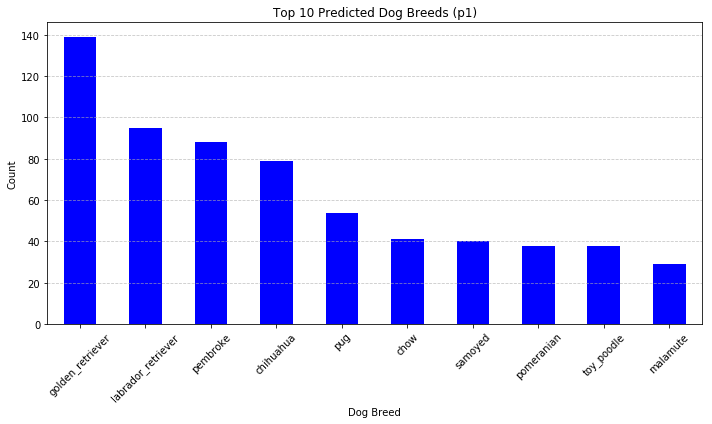

In [63]:
import matplotlib.pyplot as plt


top_breeds = master_df['p1'].value_counts().head(10)


plt.figure(figsize=(10,6))
top_breeds.plot(kind='bar', color='blue')
plt.title('Top 10 Predicted Dog Breeds (p1)')
plt.xlabel('Dog Breed')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show() ;
